# Taal AI: Deep Learning Rhythmic Beat Classification
Ishaan Shete | Winter 2026

### Project Overview
Indian Classical Music is highly improvisational and rhythmically complex, relying on intricate cycles called *Taals*. The main challenge in processing this audio is separating the percussion (Tabla) from dense acoustic noise, such as overlapping vocals and melodic instruments.

This notebook demonstrates the core machine learning pipeline of **Taal AI**. To solve the limitations of traditional machine learning (such as feature data leakage and temporal sequence compression), this system treats audio classification as a computer vision problem.

I extracted 2D Mel-Spectrograms from raw audio and utilized a Convolutional Neural Network (CNN) to visually count the spacing between drum hits across three distinct classes: **Teentaal (16 beats), Bhajani (8 beats), and Dadra (6 beats)**.

## 1. Environment Setup
First, we need to install the required audio processing libraries and import our dependencies. We use `librosa` for Digital Signal Processing (DSP) and `TensorFlow/Keras` for the Deep Learning architecture.

In [4]:
!pip install librosa tensorflow scikit-learn matplotlib numpy

import os
import librosa
import librosa.display
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from collections import Counter
import math
import warnings

warnings.filterwarnings('ignore')
print("Environment Setup Complete. TensorFlow Version:", tf.__version__)

Environment Setup Complete. TensorFlow Version: 2.19.0


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Data Transformation: Audio to Spectrograms
To prevent the neural network from suffering from "Model Collapse" (dying gradients caused by large negative decibel numbers), the audio data must be strictly scaled.

The function below converts 20-second audio chunks into 128x862 Mel-Spectrogram matrices and applies a **Min-Max Normalization** to force all pixel values into a `0.0` to `1.0` range.

Data includes 20s chunks of multi-instrument songs selectively individually picked by me. The dataset contains 1000+ such audio files in .wav format, already preprocessed and normalized, and labeled into one of 3 taals (Teentaal, Dadra, Bhajani).

In [4]:
import os
import librosa
import numpy as np
import warnings
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

# Colab Google Drive Paths
DATA_DIR = "/content/drive/MyDrive/Taal AI/processed"
#NOTE: AUDIO DATA FILES ARE LOCALLY STORED

OUTPUT_DIR = "/content/drive/MyDrive/Taal AI/cnn_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MAX_FRAMES = 862
N_MELS = 128

def audio_to_spectrogram(file_path):
    try:
        y, sr = librosa.load(file_path, sr=22050)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=512)
        S_DB = librosa.power_to_db(S, ref=np.max)

        # STRICT NORMALIZATION
        S_DB = (S_DB - np.min(S_DB)) / (np.max(S_DB) - np.min(S_DB) + 1e-8)

        if S_DB.shape[1] < MAX_FRAMES:
            pad_width = MAX_FRAMES - S_DB.shape[1]
            S_DB = np.pad(S_DB, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            S_DB = S_DB[:, :MAX_FRAMES]

        return S_DB
    except Exception as e:
        return None

print("Initializing Deep Learning Data Pipeline...")
classes = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
print(f"Detected {len(classes)} classes: {classes}")

X, y_labels = [], []

for label in classes:
    folder = os.path.join(DATA_DIR, label)
    print(f"Processing: [{label}]")
    files = [f for f in os.listdir(folder) if f.endswith('.wav')]
    for i, file in enumerate(files):
        file_path = os.path.join(folder, file)
        spectrogram = audio_to_spectrogram(file_path)
        if spectrogram is not None:
            X.append(spectrogram)
            y_labels.append(label)

X = np.array(X)[..., np.newaxis]
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_labels)

np.save(os.path.join(OUTPUT_DIR, 'X_data.npy'), X)
np.save(os.path.join(OUTPUT_DIR, 'y_labels.npy'), y_encoded)
np.save(os.path.join(OUTPUT_DIR, 'classes.npy'), encoder.classes_)
print(f"✅ SUCCESS! Matrices saved to Drive. Shape: {X.shape}")

Initializing Deep Learning Data Pipeline...
Detected 3 classes: ['dadra', 'teentaal', 'bhajani']
Processing: [dadra]
Processing: [teentaal]
Processing: [bhajani]
✅ SUCCESS! Matrices saved to Drive. Shape: (1073, 128, 862, 1)


## 3. CNN Training (The Inference Brain)
The model architecture is a sequential 2D CNN. During initial testing, I discovered the "Time Crush" problem: over-compressing the temporal axis during pooling layers destroyed the sequence of the drum beats, causing the model to default to short rhythmic cycles.

To solve this, we utilize `MaxPooling2D((2, 3))` to gently reduce noise without crushing the timeline, followed by a `Flatten()` layer to perfectly preserve the temporal sequence before it reaches the Dense decision engine. We also apply balanced class weights to prevent the model from developing a bias toward majority classes.

Loading Data from Drive...
Training: 858 | Validation: 215

Training on Colab GPUs...
Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.3951 - loss: 1.0503 - val_accuracy: 0.3767 - val_loss: 1.0602
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4802 - loss: 0.9625 - val_accuracy: 0.5628 - val_loss: 0.9547
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5361 - loss: 0.8795 - val_accuracy: 0.4186 - val_loss: 0.9599
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5711 - loss: 0.8282 - val_accuracy: 0.6512 - val_loss: 0.8370
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.6212 - loss: 0.7744 - val_accuracy: 0.6930 - val_loss: 0.7438
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.6573 - loss: 0.7067 - val_accuracy: 0.7163 - val_loss: 0.7115
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6923 - loss: 0.6720 - val_accuracy: 0.7070 - val_loss: 0.6913
Epoch 8/30
54/54 ━━━━━━

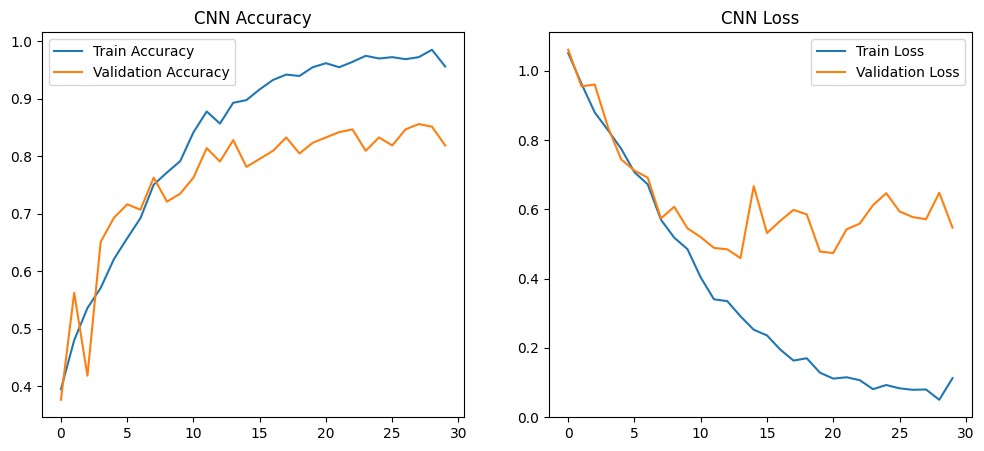

In [5]:
# Colab Google Drive Paths
DATA_DIR = "/content/drive/MyDrive/Taal AI/cnn_data"
MODEL_FILE = "/content/drive/MyDrive/Taal AI/cnn_data/taal_cnn_model.keras"

print("Loading Data from Drive...")
X = np.load(os.path.join(DATA_DIR, 'X_data.npy'))
y = np.load(os.path.join(DATA_DIR, 'y_labels.npy'))
classes = np.load(os.path.join(DATA_DIR, 'classes.npy'), allow_pickle=True)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training: {len(X_train)} | Validation: {len(X_val)}")

# THE BULLETPROOF ARCHITECTURE
model = models.Sequential([
    layers.Input(shape=(X.shape[1], X.shape[2], 1)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 3)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 3)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 3)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(classes), activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

early_stop = callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True)

print("\nTraining on Colab GPUs...")
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

model.save(MODEL_FILE)
print(f"\nModel Saved to Google Drive: {MODEL_FILE}")

# Visualizing the results right in Colab
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.legend()
plt.show()

## 4. The Inference & Voting Engine
Real-world songs are highly dynamic; they contain long, quiet introductions and vocal solos without percussion. To handle this, Taal AI uses a democratic chunk-voting engine.

The system automatically segments unseen songs into 20-second chunks. It uses `librosa.onset.onset_detect` to filter out non-percussive sections. The surviving chunks are processed by the CNN, and the individual predictions are aggregated to deliver a highly accurate, song-level verdict.

## 5. Test
*(Note: To run this cell, please ensure you have uploaded `taal_cnn_model.keras` and a sample `.wav` file into the Colab file explorer).*

We will load our pre-trained offline model and pass a raw audio file into our Inference Engine to see the chunk-by-chunk vote breakdown.

In [7]:
import os
import math
import librosa
import numpy as np
import tensorflow as tf
from collections import Counter

MAX_FRAMES = 862
N_MELS = 128

def extract_spectrogram(chunk, sr):
    """ Converts a 20s audio chunk into the required CNN input shape. """
    S = librosa.feature.melspectrogram(y=chunk, sr=sr, n_mels=N_MELS, hop_length=512)
    S_DB = librosa.power_to_db(S, ref=np.max)

    # STRICT NORMALIZATION
    S_DB = (S_DB - np.min(S_DB)) / (np.max(S_DB) - np.min(S_DB) + 1e-8)

    if S_DB.shape[1] < MAX_FRAMES:
        pad_width = MAX_FRAMES - S_DB.shape[1]
        S_DB = np.pad(S_DB, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        S_DB = S_DB[:, :MAX_FRAMES]

    return S_DB.reshape(1, N_MELS, MAX_FRAMES, 1)


def predict_song_cnn(file_path, model_instance, class_labels):
    print(f"\nAnalyzing: {os.path.basename(file_path)}...")
    try:
        y_full, sr = librosa.load(file_path, sr=22050)
    except Exception as e:
        print(f"Error: {e}")
        return

    clip_samples = 22050 * 20
    num_chunks = math.floor(librosa.get_duration(y=y_full, sr=sr) / 20)

    if num_chunks == 0:
        num_chunks = 1
        y_full = librosa.util.fix_length(y_full, size=clip_samples)

    predictions = []

    for i in range(num_chunks):
        start = i * clip_samples
        chunk = y_full[start:start + clip_samples]

        onset_env = librosa.onset.onset_strength(y=chunk, sr=sr)
        if len(librosa.onset.onset_detect(onset_envelope=onset_env, sr=sr)) < 15:
            continue

        spec_data = extract_spectrogram(chunk, sr)
        probs = model_instance.predict(spec_data, verbose=0)[0]

        # Native model prediction
        best_class = str(class_labels[np.argmax(probs)])
        predictions.append(best_class)

    if not predictions:
        print("Audio too quiet.")
        return

    vote_counts = Counter(predictions)
    winner, count = vote_counts.most_common(1)[0]

    print("-" * 30)
    print(f"CNN PREDICTED TAAL: {winner.upper()}")
    print(f"Confidence:         {(count / len(predictions)) * 100:.2f}%")
    print("Chunk Votes:", dict(vote_counts))
    print("-" * 30)


# ==========================================
# LIVE DEMONSTRATION EXECUTION
# ==========================================
try:
    # Load the pre-trained weights
    model = tf.keras.models.load_model("/content/drive/MyDrive/Taal AI/cnn_data/taal_cnn_model.keras")
    classes = np.array(['bhajani', 'dadra', 'teentaal'])
    print("Pre-trained model loaded successfully!")

    # Define the audio file to test
    test_audio_file = "/content/drive/MyDrive/Taal AI/test/Hum Tere Pyar Mein (4K) ｜ Lata Mangeshkar Romantic Song ｜ Dil Ek Mandir ｜ Raj Kumar, Meena Kumari.wav"

    # Run the prediction
    if os.path.exists(test_audio_file):
        predict_song_cnn(test_audio_file, model, classes)
    else:
        print(f"Please ensure the audio file exists at: '{test_audio_file}'")

except Exception as e:
    print(f"Warning: Could not load model. Error: {e}")

Pre-trained model loaded successfully!

Analyzing: Hum Tere Pyar Mein (4K) ｜ Lata Mangeshkar Romantic Song ｜ Dil Ek Mandir ｜ Raj Kumar, Meena Kumari.wav...
------------------------------
CNN PREDICTED TAAL: DADRA
Confidence:         71.43%
Chunk Votes: {'dadra': 10, 'bhajani': 4}
------------------------------


The above cell correctly predicts that the famous Bollywood Song, "Hum Tere Pyar Mein" by Lata Mangeshkar is in Dadra Taal!